In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nAttrition distribution:")
print(df['Attrition'].value_counts())
print("\nMissing values:", df.isnull().sum().sum())

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Missing values: 0


C:\Users\pawar\AppData\Local\Temp\ipykernel_10232\3835215242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette=['#1D9E75','#D85A30'])


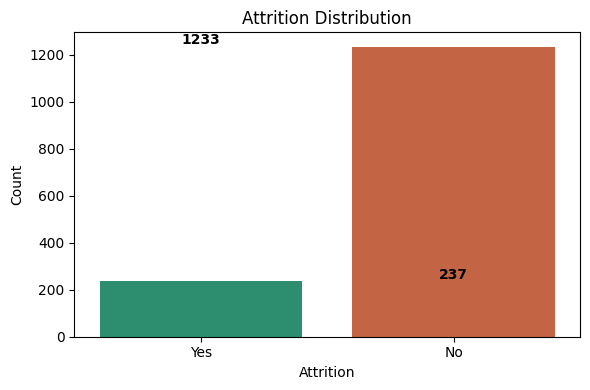

Attrition rate: 16.1 %


In [2]:
# Attrition distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df, palette=['#1D9E75','#D85A30'])
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
for i, v in enumerate([1233, 237]):
    plt.text(i, v+10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Attrition rate:", round(237/1470*100, 1), "%")

C:\Users\pawar\AppData\Local\Temp\ipykernel_10232\2927788364.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
C:\Users\pawar\AppData\Local\Temp\ipykernel_10232\2927788364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='Age', data=df,


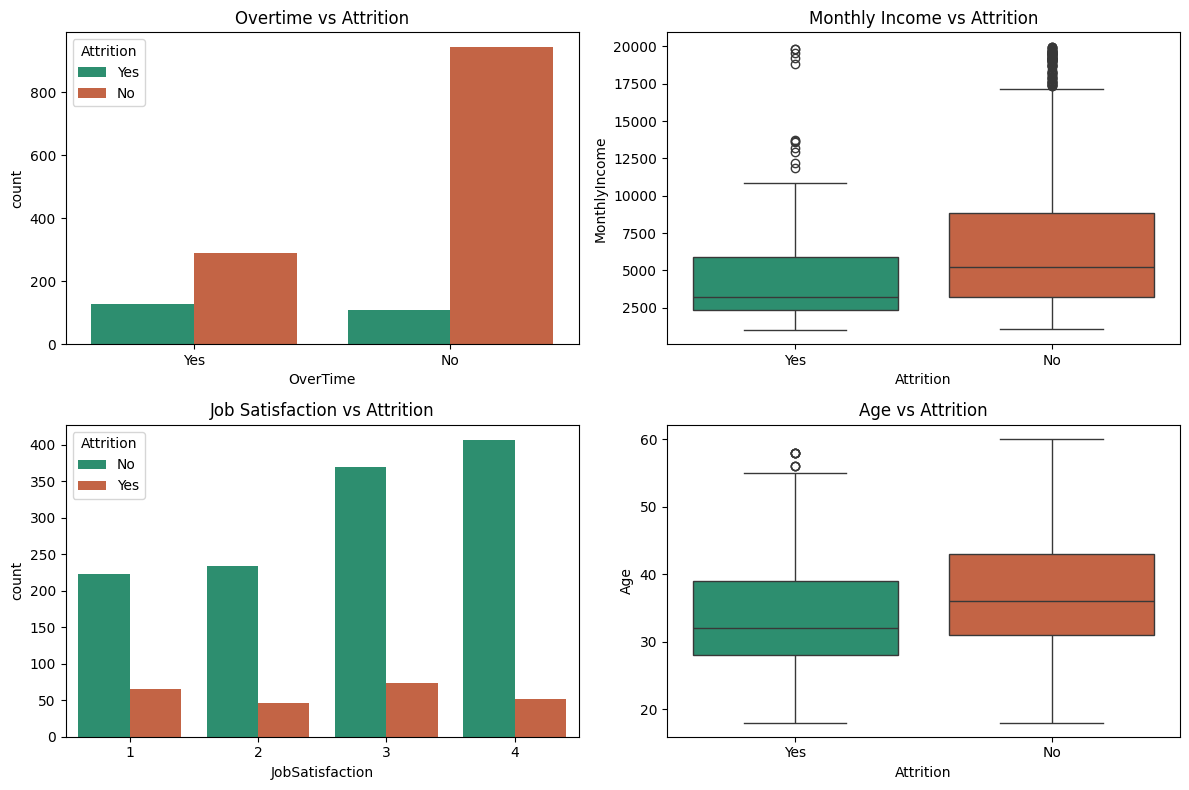

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Overtime vs Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df, 
              palette=['#1D9E75','#D85A30'], ax=axes[0,0])
axes[0,0].set_title('Overtime vs Attrition')

# Monthly Income vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette=['#1D9E75','#D85A30'], ax=axes[0,1])
axes[0,1].set_title('Monthly Income vs Attrition')

# Job Satisfaction vs Attrition
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df,
              palette=['#1D9E75','#D85A30'], ax=axes[1,0])
axes[1,0].set_title('Job Satisfaction vs Attrition')

# Age vs Attrition
sns.boxplot(x='Attrition', y='Age', data=df,
            palette=['#1D9E75','#D85A30'], ax=axes[1,1])
axes[1,1].set_title('Age vs Attrition')

plt.tight_layout()
plt.show()

In [4]:
# These 3 columns have the same value for every row - useless for ML
print("EmployeeCount unique values:", df['EmployeeCount'].unique())
print("Over18 unique values:", df['Over18'].unique())
print("StandardHours unique values:", df['StandardHours'].unique())

# Drop them
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)
print("\nNew shape after dropping useless columns:", df.shape)

EmployeeCount unique values: [1]
Over18 unique values: ['Y']
StandardHours unique values: [80]

New shape after dropping useless columns: (1470, 31)


In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Find all text columns
cat_cols = df.select_dtypes(include='object').columns
print("Categorical columns to encode:", list(cat_cols))

# Encode each one
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Verify
print("\nData types after encoding:")
print(df.dtypes.value_counts())
print("\nFirst 3 rows of encoded data:")
print(df.head(3))

# Save cleaned data
df.to_csv('cleaned_data.csv', index=False)
print("\nCleaned data saved successfully.")

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Data types after encoding:
int64    31
Name: count, dtype: int64

First 3 rows of encoded data:
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   

   Education  EducationField  EnvironmentSatisfaction  Gender  ...  \
0          2               1                        2       0  ...   
1          1               1                        3       1  ...   
2          2               4                        4       1  ...   

   PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0                  3                         1                 0   
1                  4                     

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('cleaned_data.csv')
print("Data loaded successfully:", df.shape)
print("Attrition distribution:\n", df['Attrition'].value_counts())

Data loaded successfully: (1470, 31)
Attrition distribution:
 Attrition
0    1233
1     237
Name: count, dtype: int64


In [7]:
# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining attrition distribution:")
print(y_train.value_counts())

Features shape: (1470, 30)
Target shape: (1470,)

Training set size: (1176, 30)
Testing set size: (294, 30)

Training attrition distribution:
Attrition
0    986
1    190
Name: count, dtype: int64


In [8]:
# Apply SMOTE on training data only - never on test data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("No attrition (0):", sum(y_train == 0))
print("Attrition (1):", sum(y_train == 1))

print("\nAfter SMOTE:")
print("No attrition (0):", sum(y_train_smote == 0))
print("Attrition (1):", sum(y_train_smote == 1))
print("Total training samples:", len(y_train_smote))

Before SMOTE:
No attrition (0): 986
Attrition (1): 190

After SMOTE:
No attrition (0): 986
Attrition (1): 986
Total training samples: 1972


In [9]:
# Logistic Regression - baseline model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, lr_pred))
print("F1 Score (attrition class):", 
      round(f1_score(y_test, lr_pred), 3))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       247
           1       0.32      0.51      0.39        47

    accuracy                           0.74       294
   macro avg       0.61      0.65      0.61       294
weighted avg       0.80      0.74      0.77       294

F1 Score (attrition class): 0.39


In [10]:
# XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test)

print("=== XGBoost Results ===")
print(classification_report(y_test, xgb_pred))
print("F1 Score (attrition class):", 
      round(f1_score(y_test, xgb_pred), 3))

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       247
           1       0.42      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.66      0.67      0.67       294
weighted avg       0.82      0.81      0.82       294

F1 Score (attrition class): 0.444


In [11]:
# Tuned XGBoost
xgb_tuned = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_tuned.fit(X_train_smote, y_train_smote)
xgb_tuned_pred = xgb_tuned.predict(X_test)

print("=== Tuned XGBoost Results ===")
print(classification_report(y_test, xgb_tuned_pred))
print("F1 Score (attrition class):", 
      round(f1_score(y_test, xgb_tuned_pred), 3))

=== Tuned XGBoost Results ===
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       247
           1       0.30      0.64      0.41        47

    accuracy                           0.70       294
   macro avg       0.60      0.68      0.60       294
weighted avg       0.81      0.70      0.74       294

F1 Score (attrition class): 0.405


=== Model Comparison ===
Logistic Regression F1:  0.39
XGBoost F1:              0.444
Tuned XGBoost F1:        0.405


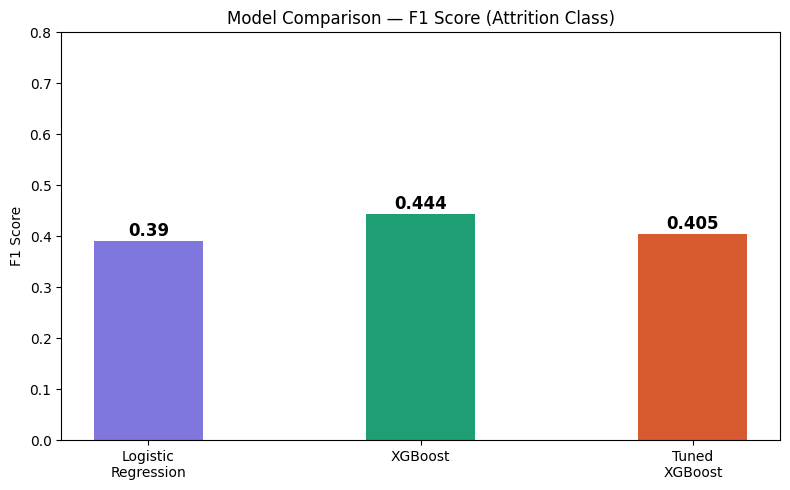

In [12]:
# Model comparison
print("=== Model Comparison ===")
print(f"Logistic Regression F1:  {round(f1_score(y_test, lr_pred), 3)}")
print(f"XGBoost F1:              {round(f1_score(y_test, xgb_pred), 3)}")
print(f"Tuned XGBoost F1:        {round(f1_score(y_test, xgb_tuned_pred), 3)}")

# Visual comparison
import matplotlib.pyplot as plt

models = ['Logistic\nRegression', 'XGBoost', 'Tuned\nXGBoost']
f1_scores = [
    round(f1_score(y_test, lr_pred), 3),
    round(f1_score(y_test, xgb_pred), 3),
    round(f1_score(y_test, xgb_tuned_pred), 3)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, f1_scores, 
               color=['#7F77DD', '#1D9E75', '#D85A30'], 
               width=0.4)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.01,
             str(score), ha='center', 
             fontweight='bold', fontsize=12)
plt.title('Model Comparison — F1 Score (Attrition Class)')
plt.ylabel('F1 Score')
plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()

In [17]:
import pickle
import os

pickle.dump(xgb_model, open('model.pkl', 'wb'))
feature_names = list(X.columns)
pickle.dump(feature_names, open('features.pkl', 'wb'))

print("model.pkl saved:", os.path.exists('model.pkl'))
print("features.pkl saved:", os.path.exists('features.pkl'))

model.pkl saved: True
features.pkl saved: True


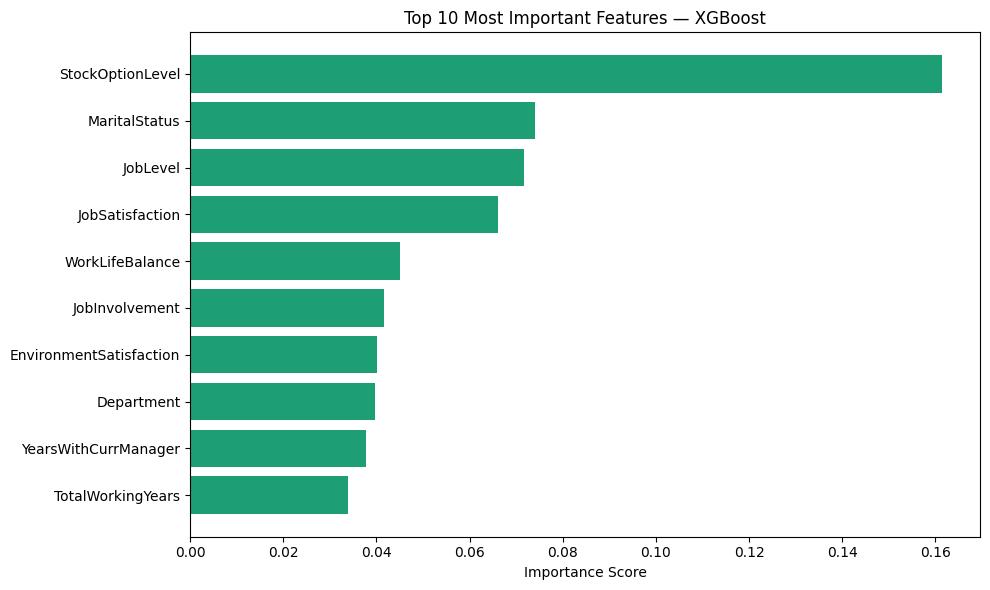


Top 5 features:
             Feature  Importance
22  StockOptionLevel    0.161479
14     MaritalStatus    0.073953
11          JobLevel    0.071753
13   JobSatisfaction    0.066090
25   WorkLifeBalance    0.044951


In [18]:
import pandas as pd

importance = xgb_model.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp['Feature'], 
         feature_imp['Importance'],
         color='#1D9E75')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features — XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(feature_imp.head())

In [19]:
import shap

# Create SHAP explainer using your XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully")
print("Shape of SHAP values:", shap_values.shape)

SHAP values calculated successfully
Shape of SHAP values: (294, 30)


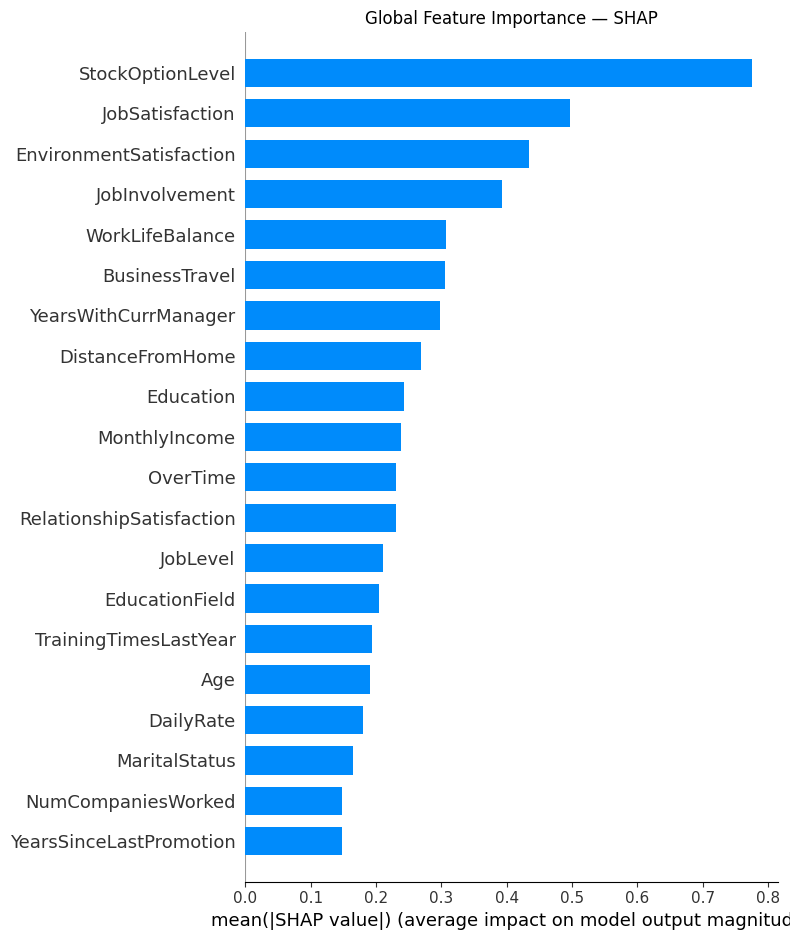

Global SHAP plot saved.


In [20]:
# Global summary plot - shows most important features overall
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  feature_names=list(X.columns),
                  plot_type="bar",
                  show=False)
plt.title("Global Feature Importance — SHAP")
plt.tight_layout()
plt.savefig('shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Global SHAP plot saved.")

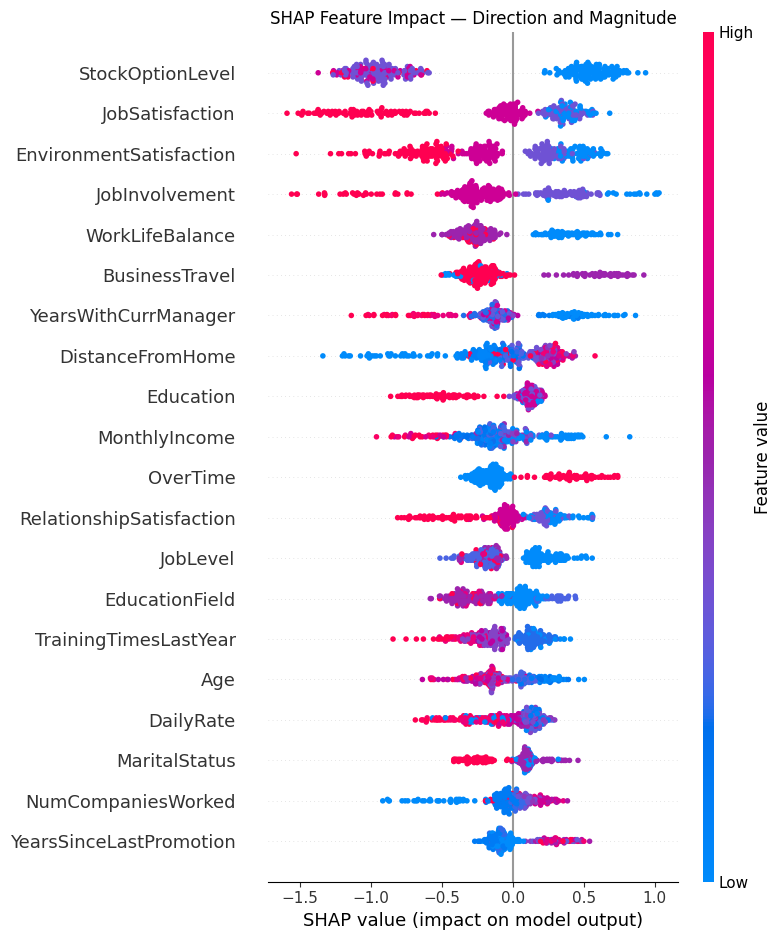

SHAP dot plot saved.


In [21]:
# Dot plot - shows direction of impact for each feature
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=list(X.columns),
                  show=False)
plt.title("SHAP Feature Impact — Direction and Magnitude")
plt.tight_layout()
plt.savefig('shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP dot plot saved.")

In [22]:
# Explain prediction for first high risk employee
# Find highest risk employee in test set
import numpy as np

proba = xgb_model.predict_proba(X_test)
highest_risk_idx = np.argmax(proba[:, 1])
print(f"Highest risk employee index: {highest_risk_idx}")
print(f"Attrition probability: {round(proba[highest_risk_idx][1]*100, 1)}%")

# Show their top risk factors
employee_shap = shap_values[highest_risk_idx]
feature_shap_df = pd.DataFrame({
    'Feature': list(X.columns),
    'SHAP Value': employee_shap
}).sort_values('SHAP Value', ascending=False)

print("\nTop 5 risk factors for this employee:")
print(feature_shap_df.head())
print("\nTop 5 protective factors:")
print(feature_shap_df.tail())

Highest risk employee index: 214
Attrition probability: 96.9000015258789%

Top 5 risk factors for this employee:
                    Feature  SHAP Value
1            BusinessTravel    0.774449
22         StockOptionLevel    0.583425
7   EnvironmentSatisfaction    0.566977
11                 JobLevel    0.513944
18                 OverTime    0.513170

Top 5 protective factors:
                 Feature  SHAP Value
14         MaritalStatus   -0.176805
29  YearsWithCurrManager   -0.189072
25       WorkLifeBalance   -0.194311
6         EducationField   -0.275368
4       DistanceFromHome   -0.362209


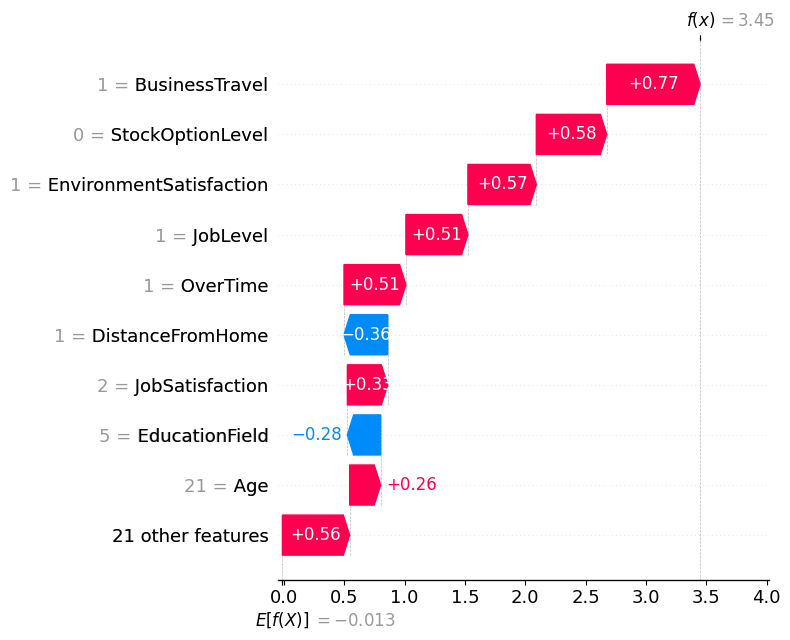

Individual SHAP explanation saved.


In [23]:
# Force plot for highest risk employee
shap.initjs()

# Waterfall plot - cleaner for individual explanation
plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[highest_risk_idx],
        feature_names=list(X.columns)
    ),
    show=False
)
plt.tight_layout()
plt.savefig('shap_individual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Individual SHAP explanation saved.")

In [24]:
# This function will be used in your Streamlit app
# It converts SHAP values into human readable text

def generate_explanation(shap_vals, feature_names, probability):
    feature_shap = pd.DataFrame({
        'Feature': feature_names,
        'SHAP Value': shap_vals
    }).sort_values('SHAP Value', ascending=False)
    
    top_risk = feature_shap.head(3)
    top_protect = feature_shap.tail(3)
    
    risk_level = "High" if probability >= 0.7 else "Medium" if probability >= 0.4 else "Low"
    
    explanation = f"""
ATTRITION RISK: {risk_level} ({round(probability*100, 1)}%)

PRIMARY RISK FACTORS:
"""
    for _, row in top_risk.iterrows():
        explanation += f"  • {row['Feature']}: +{round(row['SHAP Value'], 3)}\n"
    
    explanation += "\nPROTECTIVE FACTORS:\n"
    for _, row in top_protect.iterrows():
        explanation += f"  • {row['Feature']}: {round(row['SHAP Value'], 3)}\n"
    
    return explanation

# Test it on highest risk employee
prob = proba[highest_risk_idx][1]
explanation = generate_explanation(
    shap_values[highest_risk_idx],
    list(X.columns),
    prob
)
print(explanation)


ATTRITION RISK: High (96.9000015258789%)

PRIMARY RISK FACTORS:
  • BusinessTravel: +0.774
  • StockOptionLevel: +0.583
  • EnvironmentSatisfaction: +0.567

PROTECTIVE FACTORS:
  • WorkLifeBalance: -0.194
  • EducationField: -0.275
  • DistanceFromHome: -0.362

